In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
path_to_train_file = tf.keras.utils.get_file(
    'train.txt',
    'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt'
)
path_to_test_file = tf.keras.utils.get_file(
    'test.txt',
    'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt'
)

train_text = open(path_to_train_file, 'rb').read().decode(encoding='utf-8')
test_text = open(path_to_test_file, 'rb').read().decode(encoding='utf-8')

train_Y = np.array([
    [int(row.split('\t')[2])]
    for row in train_text.split('\n')[1:]
    if row.count('\t') > 0
])

test_Y = np.array([
    [int(row.split('\t')[2])]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
])


import re
def clean_str(string):
    string = re.sub(r"[^가-힣A-Za-z0-9(),!?\'\`]", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string)
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    string = re.sub(r"\'{2,}", "\'", string)
    string = re.sub(r"\'", "", string)
    return string.lower()
train_text_X = [row.split('\t')[1] for row in train_text.split('\n')[1:] if row.count('\t') > 0]
train_text_X = [clean_str(sentence) for sentence in train_text_X]

VOCAB_SIZE = 2000
MAX_LEN = 25
vectorize_layer = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
vectorize_layer.adapt(train_text_X)
train_X = vectorize_layer(train_text_X)


14628807/14628807 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<>:37: SyntaxWarning: invalid escape sequence '\('
<>:38: SyntaxWarning: invalid escape sequence '\)'
<>:39: SyntaxWarning: invalid escape sequence '\?'
<>:37: SyntaxWarning: invalid escape sequence '\('
<>:38: SyntaxWarning: invalid escape sequence '\)'
<>:39: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_14301/361593975.py:37: SyntaxWarning: invalid escape sequence '\('
  string = re.sub(r"\(", " \( ", string)
/tmp/ipykernel_14301/361593975.py:38: SyntaxWarning: invalid escape sequence '\)'
  string = re.sub(r"\)", " \) ", string)
/tmp/ipykernel_14301/361593975.py:39: SyntaxWarning: invalid escape sequence '\?'
  string = re.sub(r"\?", " \? ", string)


4893335/4893335 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


AI 미션 코스 2주차

In [3]:
test_text_X = [
    row.split('\t')[1]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
]

test_X = vectorize_layer(test_text_X)
print("test_X shape:", test_X.shape)
print("test_Y shape:", test_Y.shape)

VOCAB_SIZE = 2000
EMBEDDING_DIM = 128
MAX_LEN = 25
EPOCHS = 10
BATCH_SIZE = 32

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)), #입력층
    tf.keras.layers.GlobalAveragePooling1D(), #은닉층
    tf.keras.layers.Dense(64, activation='relu'), #은닉층
    tf.keras.layers.Dense(1, activation='sigmoid') #출력층
])
model.summary()

test_X shape: (50000, 25)
test_Y shape: (50000, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,321 (1.01 MB)

 Trainable params: 264,321 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_X, train_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

test_loss, test_acc = model.evaluate(test_X, test_Y, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - accuracy: 0.7219 - loss: 0.5087 - val_accuracy: 0.7571 - val_loss: 0.4639
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7509 - loss: 0.4644 - val_accuracy: 0.7524 - val_loss: 0.4663
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7544 - loss: 0.4564 - val_accuracy: 0.7593 - val_loss: 0.4543
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7568 - loss: 0.4517 - val_accuracy: 0.7601 - val_loss: 0.4545
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7564 - loss: 0.4482 - val_accuracy: 0.7472 - val_loss: 0.4672
Epoch 6/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7582 - loss: 0.4444 - val_accuracy: 0.7414 - val_loss: 0.4685
Epoch 7/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7615 - loss: 0.4407 - val_accuracy: 0.7586 - val_loss: 0.4624
Epoch 8/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7644 - loss: 0

In [5]:
example_sentences = [
    "이 영화 진짜 재미있어요",
    "완전 지루하고 별로였음",
    "배우 연기는 좋았지만 스토리가 아쉬웠다"
]

example_seq = vectorize_layer(example_sentences)
pred = model.predict(example_seq)

for s, p in zip(example_sentences, pred):
    print(f"문장: {s}")
    print(f"긍정 확률: {p[0]:.4f}")
    print("결과:", "긍정 😊" if p[0] > 0.5 else "부정 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
문장: 이 영화 진짜 재미있어요
긍정 확률: 0.9878
결과: 긍정 😊
문장: 완전 지루하고 별로였음
긍정 확률: 0.0212
결과: 부정 😞
문장: 배우 연기는 좋았지만 스토리가 아쉬웠다
긍정 확률: 0.0274
결과: 부정 😞


Epoch 수 늘려서 과적합 현상 확인


In [6]:
new_history = model.fit(
    train_X, train_Y,
    epochs=20, # 해당 모델은 이미 epochs = 10이 진행되었기 때문!!!
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7702 - loss: 0.4258 - val_accuracy: 0.7588 - val_loss: 0.4655
Epoch 2/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7722 - loss: 0.4217 - val_accuracy: 0.7550 - val_loss: 0.4690
Epoch 3/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7741 - loss: 0.4191 - val_accuracy: 0.7487 - val_loss: 0.4763
Epoch 4/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - accuracy: 0.7751 - loss: 0.4159 - val_accuracy: 0.7492 - val_loss: 0.4746
Epoch 5/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7772 - loss: 0.4130 - val_accuracy: 0.7480 - val_loss: 0.4780
Epoch 6/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7790 - loss: 0.4102 - val_accuracy: 0.7552 - val_loss: 0.4788
Epoch 7/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.7808 - loss: 0.4074 - val_accuracy: 0.7512 - val_loss: 0.4858
Epoch 8/20
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7815 - loss: 0

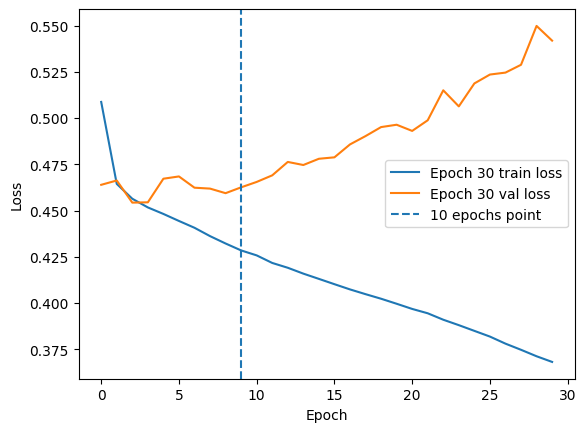

In [7]:
import matplotlib.pyplot as plt

loss = history.history['loss'] + new_history.history['loss'] # epoch = 30 모델
val_loss = history.history['val_loss'] + new_history.history['val_loss'] # epoch = 30 모델

plt.plot(loss, label = 'Epoch 30 train loss')
plt.plot(val_loss, label = 'Epoch 30 val loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.axvline(x=9, linestyle='--', label='10 epochs point') # x=0 → Epoch=1

plt.legend()
plt.show()

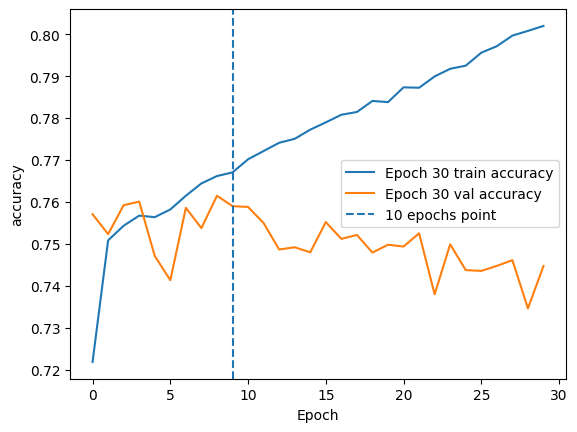

In [8]:
accuracy = history.history['accuracy'] + new_history.history['accuracy'] # epoch = 30 모델
val_accuracy = history.history['val_accuracy'] + new_history.history['val_accuracy'] # epoch = 30 모델

plt.plot(accuracy, label = 'Epoch 30 train accuracy')
plt.plot(val_accuracy, label = 'Epoch 30 val accuracy')

plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.axvline(x=9, linestyle='--', label='10 epochs point') # x=0 → Epoch=1

plt.legend()
plt.show()